# Procesamiento de lenguaje natural
# Desafio 4, LSTM Bot QA
        
### Ariel Cabello

### Datos
El objetivo es utilizar datos disponibles del challenge ConvAI2 (Conversational Intelligence Challenge 2) de conversaciones en inglés. Se construirá un BOT para responder preguntas del usuario a partir de una arquitectura `seq2seq` con `encoder-decoder` basada en `LSTM`.

In [2]:
# Si el notebook se ejecuta fuera del entorno del proyecto, esta celda asegura gdown.
!pip install --upgrade --no-cache-dir gdown --quiet
        


'pip' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
import json
import os
import pickle
import random
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Embedding, Input, LSTM
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
        


In [ ]:
# Descargar dataset y embeddings
import gdown

DATA_PATH = Path("data_volunteers.json")
GLOVE_PATH = Path("gloveembedding.pkl")

if not DATA_PATH.exists():
    data_url = "https://drive.google.com/uc?id=1awUxYwImF84MIT5-jCaYAPe2QwSgS1hN&export=download"
    gdown.download(data_url, str(DATA_PATH), quiet=False)

if not GLOVE_PATH.exists():
    glove_url = "https://drive.google.com/u/0/uc?id=1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94"
    gdown.download(glove_url, str(GLOVE_PATH), quiet=False)

print(f"Dataset listo en: {DATA_PATH.resolve()}")
print(f"Embeddings listos en: {GLOVE_PATH.resolve()}")
        


Dataset listo en: D:\ariel_D\UBA\NLP\desafios\data_volunteers.json
Embeddings listos en: D:\ariel_D\UBA\NLP\desafios\gloveembedding.pkl


In [5]:
with open(DATA_PATH, encoding="utf-8") as f:
    data = json.load(f)

print(f"Conversaciones cargadas: {len(data)}")
print(f"Campos disponibles por registro: {list(data[0].keys())}")
data[0]["dialog"][:2]
        


Conversaciones cargadas: 1111
Campos disponibles por registro: ['dialog', 'start_time', 'end_time', 'bot_profile', 'user_profile', 'eval_score', 'profile_match', 'participant1_id', 'participant2_id']


[{'id': 0,
  'sender': 'participant1',
  'text': 'hi there',
  'evaluation_score': None,
  'sender_class': 'Human'}]

In [6]:
MAX_TOKENS = 12


def clean_text(text):
    text = text.lower().strip()

    replacements = {
        "i'm": "i am",
        "you're": "you are",
        "we're": "we are",
        "they're": "they are",
        "he's": "he is",
        "she's": "she is",
        "it's": "it is",
        "that's": "that is",
        "what's": "what is",
        "where's": "where is",
        "how's": "how is",
        "don't": "do not",
        "doesn't": "does not",
        "didn't": "did not",
        "can't": "can not",
        "won't": "will not",
        "isn't": "is not",
        "aren't": "are not",
        "i've": "i have",
        "you've": "you have",
        "i'll": "i will",
        "you'll": "you will",
        "n't": " not",
        "'re": " are",
        "'ll": " will",
        "'ve": " have",
        "'d": " would",
        "'m": " am",
    }

    for old, new in replacements.items():
        text = text.replace(old, new)

    text = re.sub(r"[^a-z0-9?.!,\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


input_sentences = []
output_sentences = []
output_sentences_inputs = []

for row in data:
    dialog = row["dialog"]

    for i in range(len(dialog) - 1):
        chat_in = clean_text(dialog[i]["text"])
        chat_out = clean_text(dialog[i + 1]["text"])

        if not chat_in or not chat_out:
            continue

        if len(chat_in.split()) > MAX_TOKENS or len(chat_out.split()) > MAX_TOKENS:
            continue

        input_sentences.append(chat_in)
        output_sentences.append(chat_out + " <eos>")
        output_sentences_inputs.append("<sos> " + chat_out)

print(f"Cantidad de pares pregunta-respuesta: {len(input_sentences)}")
        


Cantidad de pares pregunta-respuesta: 11309



In [7]:
for i in range(3):
    print(f"Ejemplo {i + 1}")
    print("Pregunta:", input_sentences[i])
    print("Respuesta objetivo:", output_sentences[i])
    print("Entrada del decoder:", output_sentences_inputs[i])
    print("-" * 80)
        


Ejemplo 1
Pregunta: hello!
Respuesta objetivo: hi! how are you? <eos>
Entrada del decoder: <sos> hi! how are you?
--------------------------------------------------------------------------------
Ejemplo 2
Pregunta: hi! how are you?
Respuesta objetivo: not bad! and you? <eos>
Entrada del decoder: <sos> not bad! and you?
--------------------------------------------------------------------------------
Ejemplo 3
Pregunta: not bad! and you?
Respuesta objetivo: i am doing well. just got engaged to my high school sweetheart. <eos>
Entrada del decoder: <sos> i am doing well. just got engaged to my high school sweetheart.
--------------------------------------------------------------------------------


### 2 - Preprocesamiento
Se construyen dos tokenizadores distintos:
- uno para el encoder, que procesa la pregunta del usuario
- otro para el decoder, que genera la respuesta

Además, se agregan los tokens especiales `<sos>` y `<eos>` para marcar el inicio y el fin de la secuencia de salida.

En el encoder se usa padding a la izquierda (`pre`) y en el decoder padding a la derecha (`post`).
        


In [ ]:
MAX_VOCAB_SIZE = 8000

input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<unk>")
input_tokenizer.fit_on_texts(input_sentences)
input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)
word2idx_inputs = input_tokenizer.word_index
max_input_len = min(MAX_TOKENS, max(len(s) for s in input_integer_seq))

decoder_filters = ''.join(ch for ch in Tokenizer().filters if ch not in '<>')
output_tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    oov_token="<unk>",
    filters=decoder_filters,
)
output_tokenizer.fit_on_texts(["<sos>", "<eos>"] + output_sentences + output_sentences_inputs)
output_integer_seq = output_tokenizer.texts_to_sequences(output_sentences)
output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)
word2idx_outputs = output_tokenizer.word_index
max_out_len = min(MAX_TOKENS, max(len(s) for s in output_integer_seq))
num_words_output = min(MAX_VOCAB_SIZE, len(word2idx_outputs) + 1)

encoder_input_sequences = pad_sequences(input_integer_seq, maxlen=max_input_len, padding="pre")
decoder_input_sequences = pad_sequences(output_input_integer_seq, maxlen=max_out_len, padding="post")
decoder_output_sequences = pad_sequences(output_integer_seq, maxlen=max_out_len, padding="post")

# Se usa sparse categorical crossentropy para bajar el consumo de memoria
decoder_targets = decoder_output_sequences

print(f"Palabras en el vocabulario de entrada: {len(word2idx_inputs)}")
print(f"Palabras en el vocabulario de salida: {len(word2idx_outputs)}")
print(f"max_input_len: {max_input_len}")
print(f"max_out_len: {max_out_len}")
print(f"encoder_input_sequences shape: {encoder_input_sequences.shape}")
print(f"decoder_input_sequences shape: {decoder_input_sequences.shape}")
print(f"decoder_targets shape: {decoder_targets.shape}")


Palabras en el vocabulario de entrada: 3285
Palabras en el vocabulario de salida: 3271
max_input_len: 12
max_out_len: 12
encoder_input_sequences shape: (11309, 12)
decoder_input_sequences shape: (11309, 12)
decoder_targets shape: (11309, 12)


### 3 - Preparar los embeddings
Para el encoder se utilizaron embeddings preentrenados de `GloVe` en inglés. La idea es arrancar con una representación semántica ya aprendida y dejar fija esa capa durante el entrenamiento.

In [9]:
class WordsEmbeddings:
    def __init__(self, pkl_path, n_features):
        self.pkl_path = Path(pkl_path)
        self.n_features = n_features
        self.embeddings = self.load_model_from_pickle()
        index = np.arange(self.embeddings.shape[0])
        self.word2idx = dict(zip(self.embeddings["word"], index))
        self.idx2word = dict(zip(index, self.embeddings["word"]))

    def load_model_from_pickle(self):
        max_bytes = 2**28 - 1
        bytes_in = bytearray(0)
        input_size = os.path.getsize(self.pkl_path)

        with open(self.pkl_path, "rb") as f_in:
            for _ in range(0, input_size, max_bytes):
                bytes_in += f_in.read(max_bytes)

        return pickle.loads(bytes_in)

    def get_words_embeddings(self, words):
        words_idxs = np.array([self.word2idx.get(word, -1) for word in words])
        return self.embeddings[words_idxs]["embedding"]


class GloveEmbeddings(WordsEmbeddings):
    def __init__(self):
        super().__init__(GLOVE_PATH, n_features=50)


model_embeddings = GloveEmbeddings()
embed_dim = model_embeddings.n_features
nb_words = min(MAX_VOCAB_SIZE, len(word2idx_inputs) + 1)

embedding_matrix = np.zeros((nb_words, embed_dim), dtype="float32")
words_not_found = []

for word, idx in word2idx_inputs.items():
    if idx >= nb_words:
        continue

    embedding_vector = model_embeddings.get_words_embeddings([word])[0]
    if embedding_vector is not None and len(embedding_vector) > 0 and np.any(embedding_vector):
        embedding_matrix[idx] = embedding_vector
    else:
        words_not_found.append(word)

coverage = 1 - (len(words_not_found) / max(1, nb_words - 1))
print(f"Dimensión de embeddings: {embed_dim}")
print(f"Embedding matrix shape: {embedding_matrix.shape}")
print(f"Cobertura aproximada del vocabulario: {coverage:.2%}")
        


C:\Users\ariel\AppData\Local\Temp\ipykernel_40296\3801276015.py:19: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.loads(bytes_in)


Dimensión de embeddings: 50
Embedding matrix shape: (3286, 50)
Cobertura aproximada del vocabulario: 92.94%


### 4 - Entrenar el modelo
La arquitectura elegida sigue un esquema encoder-decoder:
- el encoder recibe la pregunta y la resume en los estados ocultos `h` y `c`
- el decoder toma esos estados y genera la respuesta palabra por palabra

Para que el notebook sea más liviano, la función de costo usada es `sparse_categorical_crossentropy`.

In [18]:
LATENT_DIM = 128
DECODER_EMBED_DIM = 128
EPOCHS = 12
BATCH_SIZE = 64

encoder_inputs = Input(shape=(max_input_len,), name="encoder_input")
encoder_embedding_layer = Embedding(
    input_dim=nb_words,
    output_dim=embed_dim,
    weights=[embedding_matrix],
    trainable=False,
    name="encoder_embedding",
)
encoder_inputs_x = encoder_embedding_layer(encoder_inputs)
encoder_outputs, state_h, state_c = LSTM(LATENT_DIM, return_state=True, name="encoder_lstm")(encoder_inputs_x)
encoder_states = [state_h, state_c]

decoder_inputs = Input(shape=(max_out_len,), name="decoder_input")
decoder_embedding_layer = Embedding(
    input_dim=num_words_output,
    output_dim=DECODER_EMBED_DIM,
    name="decoder_embedding",
)
decoder_inputs_x = decoder_embedding_layer(decoder_inputs)
decoder_lstm = LSTM(
    LATENT_DIM,
    return_sequences=True,
    return_state=True,
    dropout=0.2,
    name="decoder_lstm",
)
decoder_outputs, _, _ = decoder_lstm(decoder_inputs_x, initial_state=encoder_states)
decoder_dense = Dense(num_words_output, activation="softmax", name="decoder_dense")
decoder_outputs = decoder_dense(decoder_outputs)

model = Model([encoder_inputs, decoder_inputs], decoder_outputs, name="qa_seq2seq")
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()
        


Model: "qa_seq2seq"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 12, 50)    │    164,300 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 12, 128)   │    418,816 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 128),     │     91,648 │ encoder_embeddin… │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 12, 128), │    131,584 │ decoder_embeddin… │
│                     │ (None, 128),      │            │ encoder_lstm[0][… │
│                     │ (None, 128)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, 12, 3272)  │    422,088 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,228,436 (4.69 MB)

 Trainable params: 1,064,136 (4.06 MB)

 Non-trainable params: 164,300 (641.80 KB)

Epoch 1/12
160/160 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.5093 - loss: 3.3479 - val_accuracy: 0.5552 - val_loss: 2.6350
Epoch 2/12
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.5792 - loss: 2.4275 - val_accuracy: 0.5858 - val_loss: 2.4527
Epoch 3/12
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.6195 - loss: 2.2192 - val_accuracy: 0.6174 - val_loss: 2.2731
Epoch 4/12
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.6431 - loss: 2.0547 - val_accuracy: 0.6372 - val_loss: 2.1559
Epoch 5/12
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.6625 - loss: 1.9314 - val_accuracy: 0.6531 - val_loss: 2.0671
Epoch 6/12
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.6754 - loss: 1.8383 - val_accuracy: 0.6625 - val_loss: 2.0063
Epoch 7/12
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.6823 - loss: 1.7681 - val_accuracy: 0.6656 - val_loss: 1.9618
Epoch 8/12
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.6858 - loss: 1.7112 - val_accu

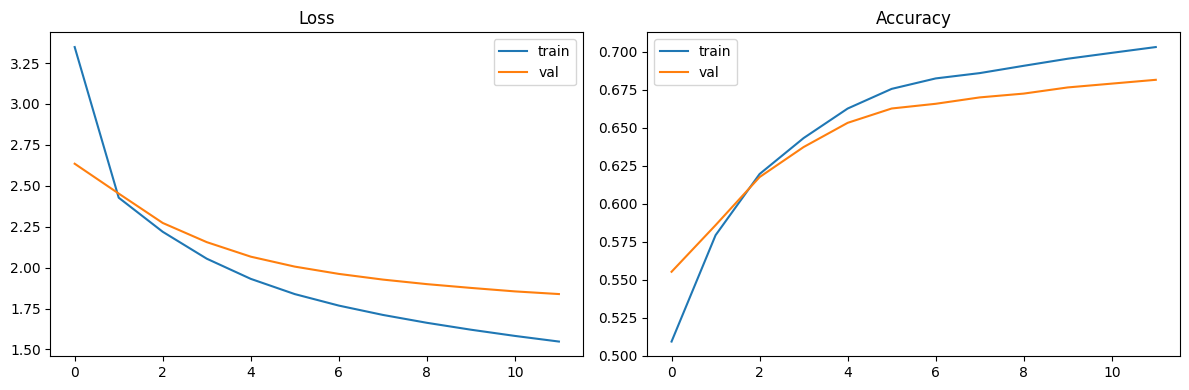

In [19]:
early_stopping = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

history = model.fit(
    [encoder_input_sequences, decoder_input_sequences],
    decoder_targets,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()
        


### 5 - Inferencia
La inferencia se hace con dos modelos separados:
- `encoder_model`, que transforma la pregunta en estados internos
- `decoder_model`, que genera la respuesta de forma autoregresiva

El proceso arranca con el token `<sos>` y termina cuando el modelo predice `<eos>` o cuando se llega a la longitud máxima de salida.
        


In [12]:
encoder_model = Model(encoder_inputs, encoder_states, name="encoder_inference")

decoder_state_input_h = Input(shape=(LATENT_DIM,), name="decoder_state_h")
decoder_state_input_c = Input(shape=(LATENT_DIM,), name="decoder_state_c")
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

decoder_inputs_single = Input(shape=(1,), name="decoder_token_input")
decoder_inputs_single_x = decoder_embedding_layer(decoder_inputs_single)
decoder_outputs_inf, state_h_inf, state_c_inf = decoder_lstm(
    decoder_inputs_single_x,
    initial_state=decoder_states_inputs,
)
decoder_outputs_inf = decoder_dense(decoder_outputs_inf)
decoder_model = Model(
    [decoder_inputs_single] + decoder_states_inputs,
    [decoder_outputs_inf, state_h_inf, state_c_inf],
    name="decoder_inference",
)

idx2word_outputs = {idx: word for word, idx in word2idx_outputs.items()}


def decode_response(input_sequence):
    states_value = encoder_model.predict(input_sequence, verbose=0)

    target_seq = np.zeros((1, 1), dtype="int32")
    target_seq[0, 0] = word2idx_outputs["<sos>"]
    eos_idx = word2idx_outputs["<eos>"]

    output_tokens = []

    for _ in range(max_out_len):
        output_probs, h, c = decoder_model.predict([target_seq] + states_value, verbose=0)
        sampled_token_idx = int(np.argmax(output_probs[0, 0, :]))

        if sampled_token_idx in (0, eos_idx):
            break

        sampled_word = idx2word_outputs.get(sampled_token_idx, "<unk>")
        output_tokens.append(sampled_word)

        target_seq[0, 0] = sampled_token_idx
        states_value = [h, c]

    return " ".join(output_tokens)


def chat(text):
    clean_input = clean_text(text)
    integer_seq = input_tokenizer.texts_to_sequences([clean_input])
    padded_seq = pad_sequences(integer_seq, maxlen=max_input_len, padding="pre")
    return decode_response(padded_seq)
        


In [13]:
# Pruebas sobre algunas preguntas del dataset.
for idx in [0, 10, 100]:
    print("Pregunta:", input_sentences[idx])
    print("Respuesta esperada:", output_sentences[idx])
    print("Respuesta generada:", chat(input_sentences[idx]))
    print("-" * 80)
        


Pregunta: hello!
Respuesta esperada: hi! how are you? <eos>
Respuesta generada: hi how are you
--------------------------------------------------------------------------------
Pregunta: hi!
Respuesta esperada: hello! <eos>
Respuesta generada: hello how are you
--------------------------------------------------------------------------------
Pregunta: just working on building a computer
Respuesta esperada: when will you finish? <eos>
Respuesta generada: i am a lot of friends
--------------------------------------------------------------------------------


In [14]:
# Pruebas libres.
questions = [
    "hello",
    "what do you do?",
    "where are you from?",
    "do you like music?",
]

for question in questions:
    print("Usuario:", question)
    print("Bot:", chat(question))
    print("-" * 80)
        


Usuario: hello
Bot: hi how are you
--------------------------------------------------------------------------------
Usuario: what do you do?
Bot: i am a lot of friends
--------------------------------------------------------------------------------
Usuario: where are you from?
Bot: i am a good day
--------------------------------------------------------------------------------
Usuario: do you like music?
Bot: i am a lot of friends
--------------------------------------------------------------------------------


### Conclusiones
El entrenamiento corre las 12 épocas completas: el `EarlyStopping` con `patience=2` nunca se dispara porque el `val_loss` baja de forma monótona (de 2.63 a 1.84). Los valores finales son `loss=1.55`, `accuracy=0.70` en train y `loss=1.84`, `accuracy=0.68` en validación. El gap entre ambas curvas es chico, pero el `val_loss` seguía cayendo en la última época, así que el modelo probablemente quedó corto de entrenamiento. Con más épocas o una `patience` mayor seguramente habría rascado un poco más.

En las respuestas generadas se ven dos patrones típicos del `seq2seq` chico:

- **Mode collapse**: `i am a lot of friends` aparece para tres preguntas distintas (`what do you do?`, `just working on building a computer`, `do you like music?`). El decoder se ancla en una frase frecuente del corpus sin importar el contexto codificado.
- **Salidas agramaticales**: `i am a good day` para `where are you from?`. El decoder aprende el arranque plausible `i am a...` pero el vector de contexto no alcanza para condicionar bien la continuación.

Los saludos sí funcionan razonablemente (`hello!` -> `hi how are you`, `hi!` -> `hello how are you`), probablemente por ser los pares más frecuentes del corpus.

Todo esto es consistente con el cuello de botella del `seq2seq` sin atención: la pregunta entera se comprime en un único vector de 128 dimensiones y, con 11.309 pares, la señal no alcanza para que el decoder diversifique. Para mejorar sin cambiar de arquitectura habría que subir `LATENT_DIM` (por ejemplo a 256) y entrenar más épocas; el salto conceptual siguiente sería  agregar atención.
